# Day 04：手写 MLP —— 用代码解决 XOR 问题

> ☀️ 第二周 · 破局与复兴 · 第 4 天

前三天的内容合在一起，就是一个完整的神经网络：

隐藏层（空间变换）+ 非线性激活（可导可学）+ 反向传播（自动调参）

今天把这三块拼起来，用 PyTorch 实现一个完整的 MLP，并用它彻底解决 XOR 问题！

**今天的任务**：用 PyTorch 的 autograd 实现自动反向传播，训练 MLP 解决 XOR。

---

## 1. PyTorch 的自动求导机制

昨天我们手写了反向传播的每一步。今天用 PyTorch 的 `autograd` 简化它。

核心思想：**只写前向传播，梯度自动计算！**

In [1]:
import torch

# PyTorch 自动求导示例
x = torch.tensor([[1.0, 2.0]], requires_grad=True)
W = torch.tensor([[3.0], [4.0]], requires_grad=True)
b = torch.tensor([[5.0]], requires_grad=True)

# 前向传播
z = torch.matmul(x, W) + b
y = torch.sigmoid(z)
loss = (y - 0.5)**2  # 假设目标是 0.5

print("前向传播完成！")
print(f"  x = {x}")
print(f"  W = {W.t()}")
print(f"  b = {b}")
print(f"  z = {z}")
print(f"  y = {y}")
print(f"  loss = {loss.item():.4f}")

# 反向传播（一行搞定！）
loss.backward()

print("\n反向传播完成！梯度：")
print(f"  x.grad = {x.grad}")
print(f"  W.grad = {W.grad}")
print(f"  b.grad = {b.grad}")

print("\n✅ 只需要：")
print("   1. 设置 requires_grad=True")
print("   2. 做前向传播")
print("   3. 调用 loss.backward()")
print("   4. W.grad 就是 ∂L/∂W！")

前向传播完成！
  x = tensor([[1., 2.]], requires_grad=True)
  W = tensor([[3., 4.]], grad_fn=<TBackward0>)
  b = tensor([[5.]], requires_grad=True)
  z = tensor([[16.]], grad_fn=<AddBackward0>)
  y = tensor([[1.0000]], grad_fn=<SigmoidBackward0>)
  loss = 0.2500

反向传播完成！梯度：
  x.grad = tensor([[3.5763e-07, 4.7684e-07]])
  W.grad = tensor([[1.1921e-07],
        [2.3842e-07]])
  b.grad = tensor([[1.1921e-07]])

✅ 只需要：
   1. 设置 requires_grad=True
   2. 做前向传播
   3. 调用 loss.backward()
   4. W.grad 就是 ∂L/∂W！


---

## 2. 用 PyTorch 实现 MLP 类

现在用 PyTorch 的方式实现一个完整的 MLP：

```
MLP(
  Linear(2, 4)    <- 第一层：2个输入 -> 4个隐藏
  Sigmoid()       <- 激活
  Linear(4, 1)    <- 第二层：4个隐藏 -> 1个输出
  Sigmoid()       <- 激活
)
```

In [2]:
class MLP(torch.nn.Module):
    """
    用 PyTorch 实现的 MLP
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        # 第一层：线性变换
        self.linear1 = torch.nn.Linear(input_size, hidden_size)
        
        # 激活函数
        self.activation = torch.nn.Sigmoid()
        
        # 第二层：线性变换
        self.linear2 = torch.nn.Linear(hidden_size, output_size)
        
        # Output激活（也是 Sigmoid，用于二分类）
        self.output_activation = torch.nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.output_activation(x)
        return x

# 创建模型
model = MLP(input_size=2, hidden_size=4, output_size=1)

print("\nMLP Architecture:")
print(model)

# 查看初始权重
print("\nInitial weights (random):")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}")


MLP Architecture:
MLP(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (activation): Sigmoid()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
  (output_activation): Sigmoid()
)

Initial weights (random):
  linear1.weight: shape=torch.Size([4, 2])
  linear1.bias: shape=torch.Size([4])
  linear2.weight: shape=torch.Size([1, 4])
  linear2.bias: shape=torch.Size([1])


---

## 3. 训练循环

完整的训练过程：

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
criterion = torch.nn.MSELoss()

for epoch in range(epochs):
    optimizer.zero_grad()   # 清零梯度
    y_pred = model(x)       # 前向传播
    loss = criterion(...)  # 计算损失
    loss.backward()        # 反向传播
    optimizer.step()       # 更新权重
```

In [3]:
# XOR 数据
X_xor = torch.tensor([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
], dtype=torch.float32)
y_xor = torch.tensor([[1.0], [0.0], [0.0], [1.0]], dtype=torch.float32)

# 创建模型
model = MLP(input_size=2, hidden_size=8, output_size=1)

# 优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.5)
criterion = torch.nn.MSELoss()

# Training
print("Training XOR...")
print("="*60)

losses = []
for epoch in range(500):
    # 清零梯度
    optimizer.zero_grad()
    
    # 前向传播
    y_pred = model(X_xor)
    
    # 计算损失
    loss = criterion(y_pred, y_xor)
    losses.append(loss.item())
    
    # 反向传播
    loss.backward()
    
    # 更新权重
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss.item():.4f}")

print("\nTraining complete!")

Training XOR...
Epoch 100: Loss = 0.0006
Epoch 200: Loss = 0.0002
Epoch 300: Loss = 0.0001
Epoch 400: Loss = 0.0001
Epoch 500: Loss = 0.0001

Training complete!


---

## 4. 验证结果

In [4]:
# 设置中文字体（解决 matplotlib 显示中文问题）
import matplotlib.pyplot as plt
import matplotlib
# 尝试使用系统可用的中文字体
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
except:
    pass


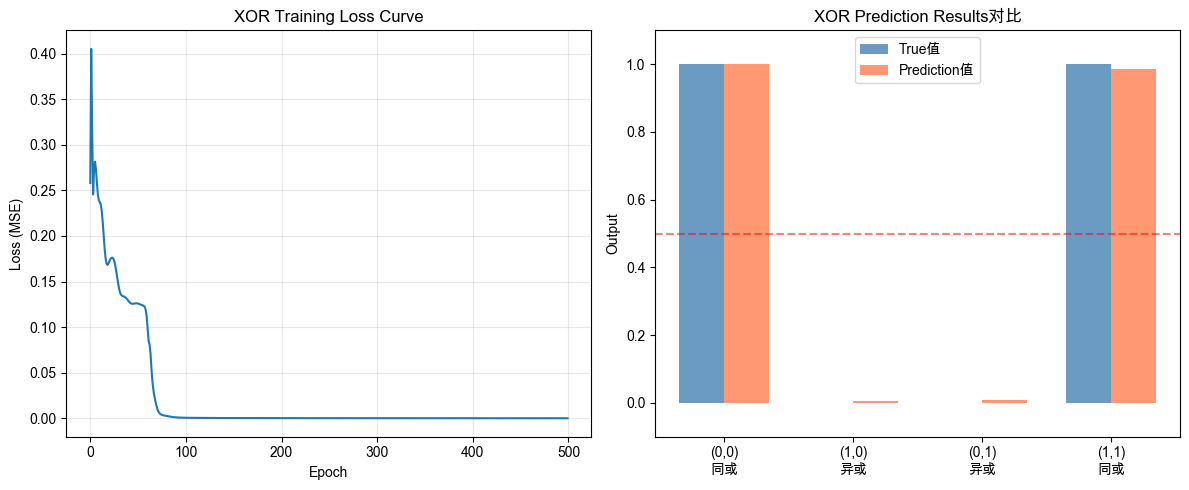


Detailed Prediction Results:
  (0, 0): True=1, Prediction=1 (Prob=0.9998) ✓
  (1, 0): True=0, Prediction=0 (Prob=0.0069) ✓
  (0, 1): True=0, Prediction=0 (Prob=0.0070) ✓
  (1, 1): True=1, Prediction=1 (Prob=0.9873) ✓


In [5]:
# Test
model.eval()
with torch.no_grad():
    y_pred = model(X_xor)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 损失曲线
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('XOR Training Loss Curve')
axes[0].grid(True, alpha=0.3)

# PredictionResult对比
categories = ['(0,0)\n同或', '(1,0)\n异或', '(0,1)\n异或', '(1,1)\n同或']
x_pos = np.arange(len(categories))
width = 0.35

bars1 = axes[1].bar(x_pos - width/2, y_xor.flatten().tolist(), width, 
                     label='True值', color='steelblue', alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, y_pred.flatten().tolist(), width,
                     label='Prediction值', color='coral', alpha=0.8)

axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Output')
axes[1].set_title('XOR Prediction Results对比')
axes[1].legend()
axes[1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('xor_mlp_results.png', dpi=150)
plt.show()

print("\nDetailed Prediction Results:")
print("="*50)
for i in range(4):
    x_str = f"({int(X_xor[i,0].item())}, {int(X_xor[i,1].item())})"
    true_val = int(y_xor[i].item())
    pred_prob = y_pred[i].item()
    pred_val = 1 if pred_prob > 0.5 else 0
    status = "✓" if true_val == pred_val else "✗"
    print(f"  {x_str}: True={true_val}, Prediction={pred_val} (Prob={pred_prob:.4f}) {status}")

---

## 5. 可视化学习到的决策边界

让我们可视化 MLP 学到的决策边界。

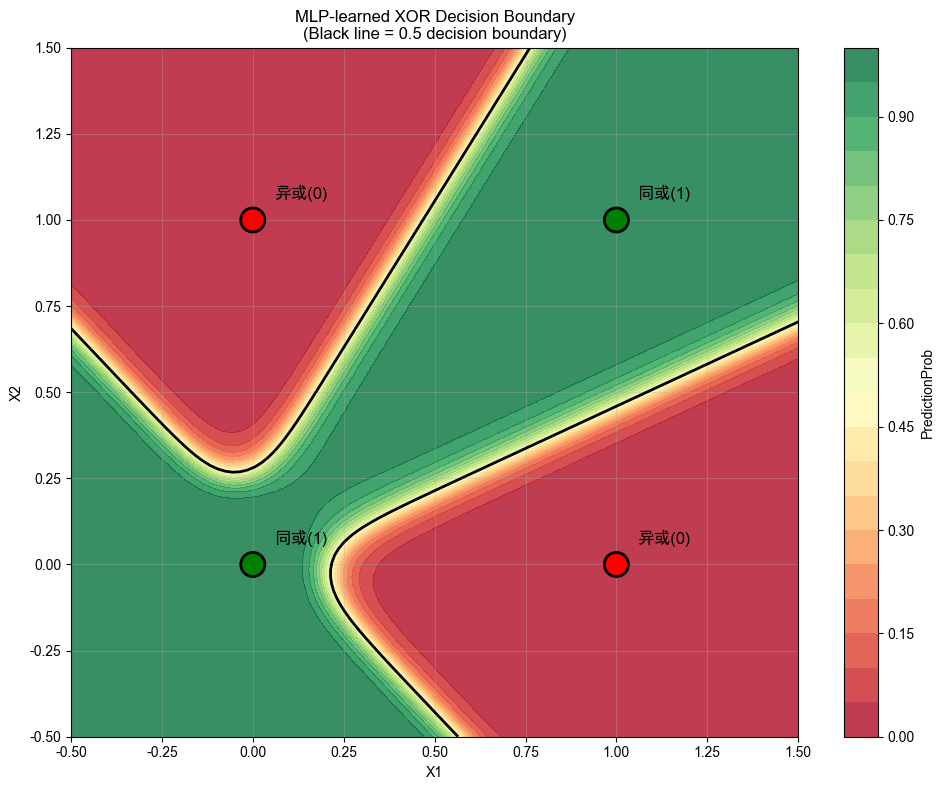


✅ 看！MLP 学到了一条弯曲的决策边界！
   这正是隐藏层的功劳——它把线性不可分的问题变换到了线性可分的空间。


In [6]:
# 创建网格
x1_range = np.linspace(-0.5, 1.5, 100)
x2_range = np.linspace(-0.5, 1.5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# 网格点Prediction
grid_points = torch.tensor(np.column_stack([X1.ravel(), X2.ravel()]), dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_grid = model(grid_points).numpy().reshape(X1.shape)

# 可视化
plt.figure(figsize=(10, 8))

# 决策边界热力图
contour = plt.contourf(X1, X2, y_grid, levels=20, cmap='RdYlGn', alpha=0.8)
plt.colorbar(contour, label='PredictionProb')

# 决策边界线
plt.contour(X1, X2, y_grid, levels=[0.5], colors='black', linewidths=2)

# 绘制数据点
colors = ['green' if y == 1 else 'red' for y in y_xor.numpy()]
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=300, edgecolors='black', linewidth=2, zorder=5)

# 标注
for i in range(4):
    label = '同或(1)' if y_xor[i] == 1 else '异或(0)'
    plt.annotate(label, (X_xor[i, 0], X_xor[i, 1]), 
                 textcoords="offset points", xytext=(15, 15), 
                 fontsize=12, fontproperties=None)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('MLP-learned XOR Decision Boundary\n(Black line = 0.5 decision boundary)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xor_decision_boundary.png', dpi=150)
plt.show()

print("\n✅ 看！MLP 学到了一条弯曲的决策边界！")
print("   这正是隐藏层的功劳——它把线性不可分的问题变换到了线性可分的空间。")

---

## 6. 对比：单层 vs 多层

让我们对比单层感知机和 MLP 的表现。

/var/folders/8j/y1d6rhz547zg9vsg7mw95nwc0000gn/T/ipykernel_1164/4023181243.py:42: UserWarning: The following kwargs were not used by contour: 'linewidth'
  plt.contour(X1, X2, y_grid_single, levels=[0.5], colors='black', linewidth=2)


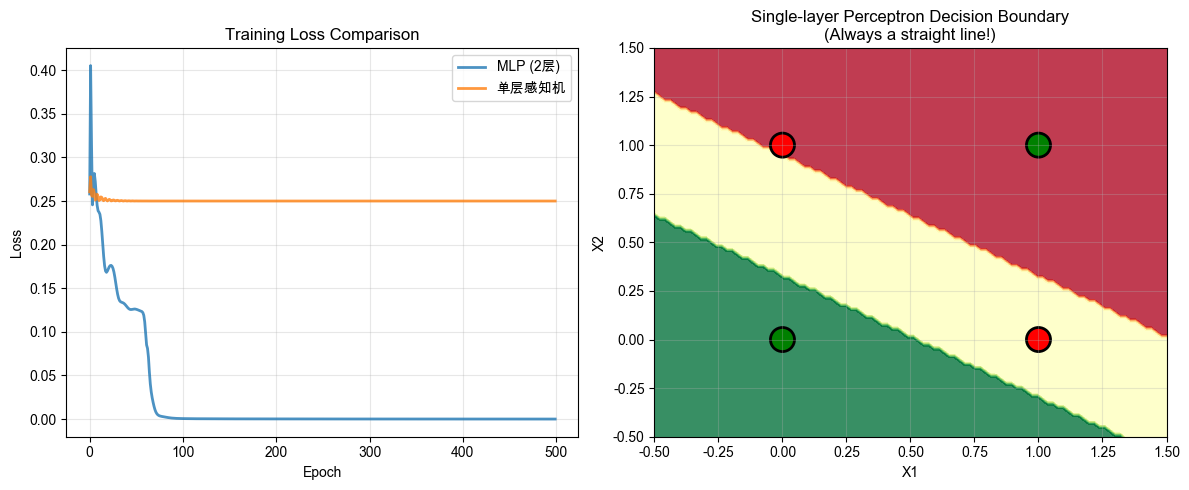


Comparison Results:
Single-layer Perceptron (no hidden layer):
  (0, 0) -> 0 (True: 1)
  (1, 0) -> 0 (True: 0)
  (0, 1) -> 0 (True: 0)
  (1, 1) -> 0 (True: 1)

MLP (with hidden layer):
  (0, 0) -> 1 (True: 1)
  (1, 0) -> 0 (True: 0)
  (0, 1) -> 0 (True: 0)
  (1, 1) -> 1 (True: 1)

📝 Conclusion: Single-layer perceptron can never solve XOR because its decision boundary is a straight line!
   MLP achieves non-linear decision boundary through hidden layer, successfully solving XOR.


In [7]:
class SingleLayerPerceptron(torch.nn.Module):
    """单层感知机（无隐藏层）"""
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(2, 1)
        self.activation = torch.nn.Sigmoid()
        
    def forward(self, x):
        return self.activation(self.linear(x))

# Training单层感知机
single_layer = SingleLayerPerceptron()
optimizer_single = torch.optim.Adam(single_layer.parameters(), lr=0.5)

losses_single = []
for epoch in range(500):
    optimizer_single.zero_grad()
    y_pred = single_layer(X_xor)
    loss = criterion(y_pred, y_xor)
    losses_single.append(loss.item())
    loss.backward()
    optimizer_single.step()

# 可视化对比
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, label='MLP (2层)', alpha=0.8, linewidth=2)
plt.plot(losses_single, label='单层感知机', alpha=0.8, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Single-layer Perceptron Decision Boundary
with torch.no_grad():
    y_grid_single = single_layer(grid_points).numpy().reshape(X1.shape)

plt.subplot(1, 2, 2)
plt.contourf(X1, X2, y_grid_single, levels=20, cmap='RdYlGn', alpha=0.8)
plt.contour(X1, X2, y_grid_single, levels=[0.5], colors='black', linewidth=2)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=300, edgecolors='black', linewidth=2)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Single-layer Perceptron Decision Boundary\n(Always a straight line!)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('single_vs_multi_layer.png', dpi=150)
plt.show()

print("\nComparison Results:")
print("="*50)
single_layer.eval()
with torch.no_grad():
    y_single = single_layer(X_xor)
    
print("Single-layer Perceptron (no hidden layer):")
for i in range(4):
    pred = 1 if y_single[i].item() > 0.5 else 0
    true = int(y_xor[i].item())
    print(f"  ({int(X_xor[i,0])}, {int(X_xor[i,1])}) -> {pred} (True: {true})")

print("\nMLP (with hidden layer):")
model.eval()
with torch.no_grad():
    y_mlp = model(X_xor)
for i in range(4):
    pred = 1 if y_mlp[i].item() > 0.5 else 0
    true = int(y_xor[i].item())
    print(f"  ({int(X_xor[i,0])}, {int(X_xor[i,1])}) -> {pred} (True: {true})")

print("\n📝 Conclusion: Single-layer perceptron can never solve XOR because its decision boundary is a straight line!")
print("   MLP achieves non-linear decision boundary through hidden layer, successfully solving XOR.")

---

## 今日总结

| 概念 | 实现方式 |
|------|----------|
| 自动求导 | `torch.autograd`，设置 `requires_grad=True` |
| 前向传播 | `y_pred = model(x)` |
| 反向传播 | `loss.backward()` |
| 梯度清零 | `optimizer.zero_grad()` |
| 参数更新 | `optimizer.step()` |

**MLP 解决 XOR 的关键**：
1. 隐藏层：把输入空间变换到新空间
2. 非线性激活：让变换后的点线性可分
3. 反向传播：自动学习最优的变换

**明天预告**：今天我们用 MSE 作为损失函数。但对于分类任务，有更好的选择——**交叉熵损失**。明天学习损失函数的选择和梯度下降的更多细节。